# Disorder Estimation from Diffraction Patterns

In this notebook, we test whether the positional disorder level of a finite square lattice can be estimated directly from its diffraction pattern.

The input is the log-intensity diffraction image, and the target is the positional jitter level \( \sigma \).

We begin with a simple baseline model before considering more advanced learning approaches.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
def create_lattice(n_points=10, grid_size=128, jitter_sigma=0.0):
    img = np.zeros((grid_size, grid_size))

    spacing = grid_size / (n_points + 2)
    coords = np.arange(n_points) * spacing
    lattice_span = coords[-1] - coords[0]
    start = (grid_size - lattice_span) / 2.0

    for i in range(n_points):
        for j in range(n_points):
            x = start + i * spacing
            y = start + j * spacing

            x += np.random.normal(0, jitter_sigma * spacing)
            y += np.random.normal(0, jitter_sigma * spacing)

            xi = int(np.clip(round(x), 0, grid_size - 1))
            yi = int(np.clip(round(y), 0, grid_size - 1))

            img[yi, xi] = 1.0

    return img


def compute_diffraction(img, normalize=True):
    F = np.fft.fftshift(np.fft.fft2(img))
    I = np.abs(F)**2
    I_log = np.log1p(I)

    if normalize:
        I_log = (I_log - I_log.min()) / (I_log.max() - I_log.min() + 1e-8)

    return I_log

In [5]:
sigmas = np.linspace(0.00, 0.20, 11)
samples_per_sigma = 200

n_points = 10
grid_size = 128

In [6]:
X = []
y = []

for sigma in sigmas:
    for _ in range(samples_per_sigma):
        img = create_lattice(
            n_points=n_points,
            grid_size=grid_size,
            jitter_sigma=sigma
        )
        diff = compute_diffraction(img, normalize=True)

        X.append(diff)
        y.append(sigma)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 128, 128)
y shape: (2200,)


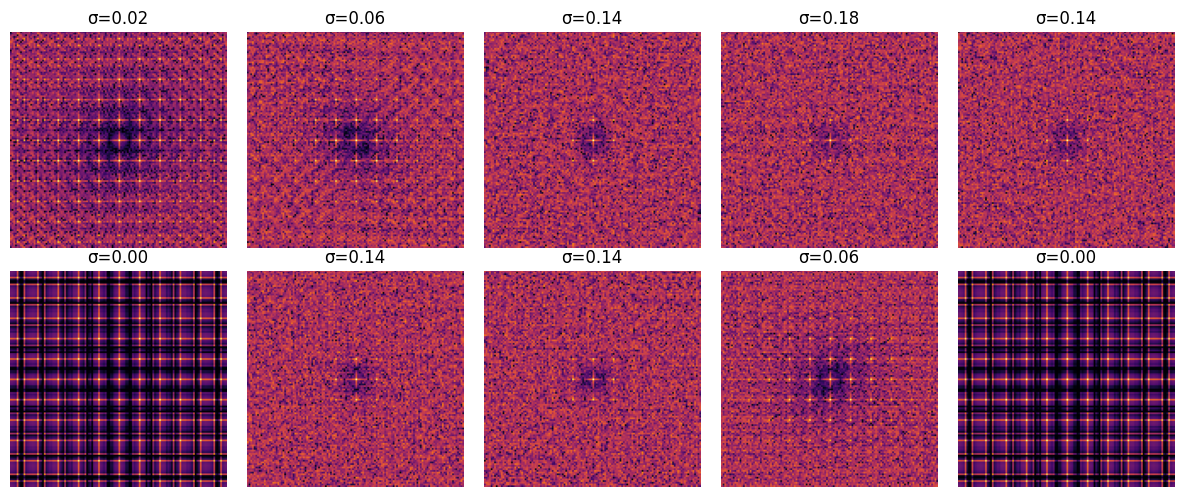

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, np.random.choice(len(X), size=10, replace=False)):
    ax.imshow(X[idx], cmap='inferno')
    ax.set_title(f"σ={y[idx]:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
X_flat = X.reshape(len(X), -1)

print("Flattened X shape:", X_flat.shape)

Flattened X shape: (2200, 16384)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1760
Test size: 440


In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R^2  : {r2:.4f}")

MAE  : 0.0036
RMSE : 0.0061
R^2  : 0.9911


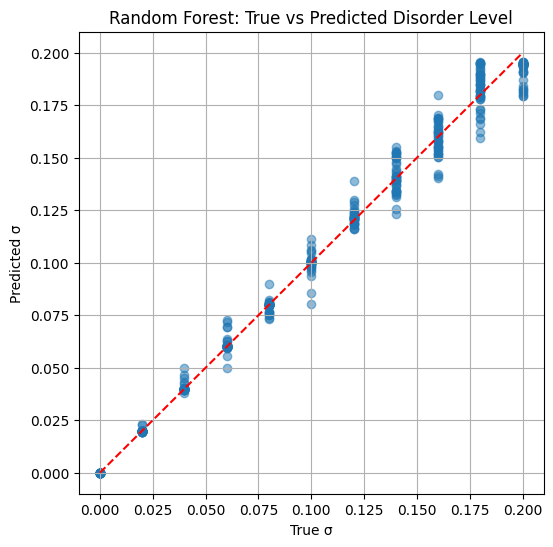

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True σ")
plt.ylabel("Predicted σ")
plt.title("Random Forest: True vs Predicted Disorder Level")
plt.grid(True)
plt.show()

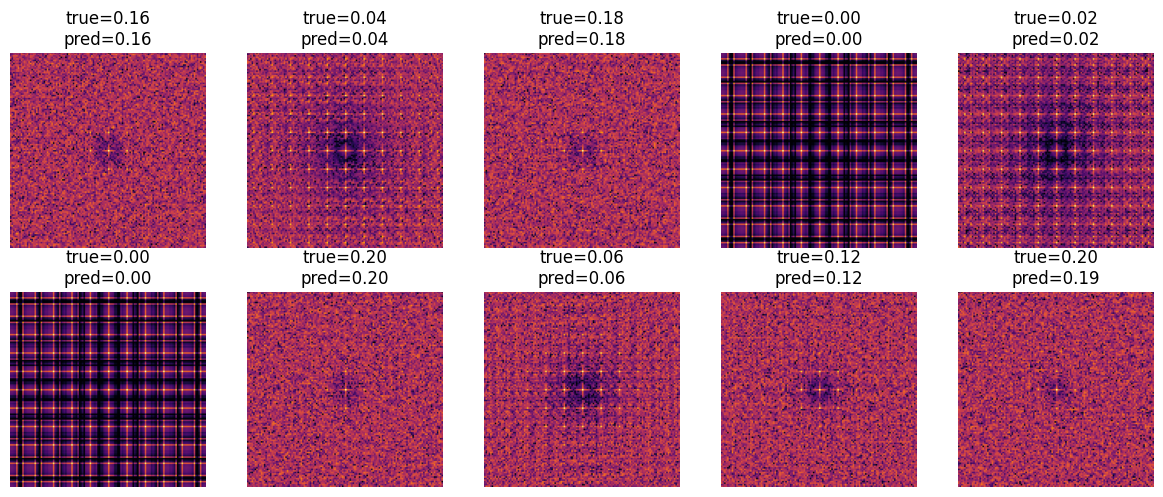

In [13]:
test_indices = np.random.choice(len(X_test), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, test_indices):
    img_2d = X_test[idx].reshape(grid_size, grid_size)
    true_sigma = y_test[idx]
    pred_sigma = y_pred[idx]

    ax.imshow(img_2d, cmap='inferno')
    ax.set_title(f"true={true_sigma:.2f}\npred={pred_sigma:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

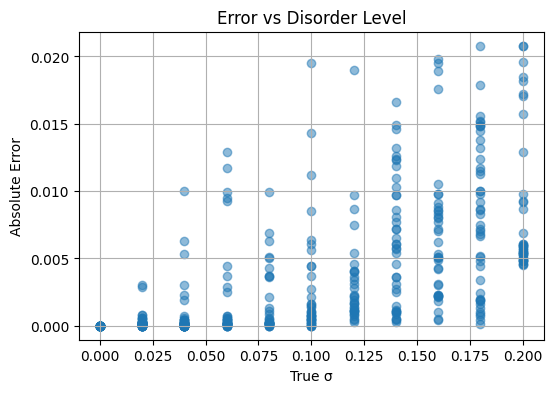

In [14]:
errors = np.abs(y_test - y_pred)

plt.figure(figsize=(6,4))
plt.scatter(y_test, errors, alpha=0.5)
plt.xlabel("True σ")
plt.ylabel("Absolute Error")
plt.title("Error vs Disorder Level")
plt.grid(True)
plt.show()

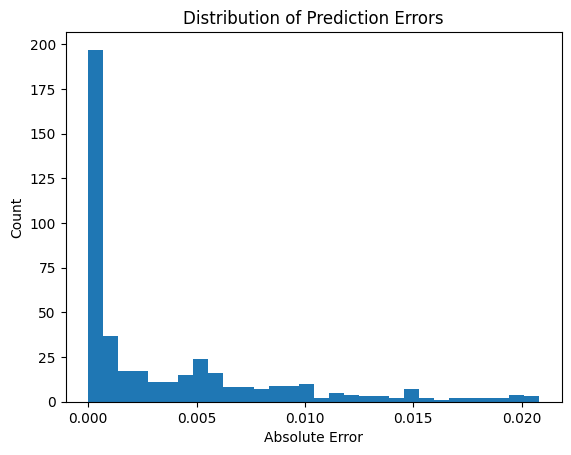

In [15]:
plt.hist(errors, bins=30)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.show()